## Introducción a la solución de EDOs
### Juan S. Hincapié - Carlos Duque-Daza

# Esquemas de Integracion
Metodos numericos que permiten solucion de ecuaciones diferenciales en este caso $y'=f(t,y(t),\alpha)$ Euler hacía delante es uno de ellos.
\
Plantee como $\frac{(y(t)-y(t=0)}{t_{i+1}-t_i}=\int_{t=0}^{t}(t=0,y(t=0),\alpha)$



In [8]:
dy = lambda x, y: (0.005*x-0.3)*y
dx = lambda x, y: (-0.01*y+0.4)*x
print(dy(80, 40))
print(dx(80,40))
print(dy(60,60))
print(dx(60,60))
print(f'{dy(80,20):.0f}')
print(f'{dx(80,20):.1f}')


4.000000000000002
0.0
0.0
-11.999999999999996
2
16.0


In [3]:
!pip install numpy
!pip install matplotlib
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 27.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 25.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 29.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 27.8 MB/s  0:00:00m0:00:010:01


In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
t = [0.1*x for x in range(4)]
len(t)
y = np.zeros(4)
y = np.array(y)
for i in range(4):
  y[i] = t[i]
print(type(y) == type(t))

False


1.0

### El método de  Euler Hacia Adelante (Forward Euler)

> Añadir blockquote



<div align='justify'>El método de Euler hacia adelante es un procedimiento numérico empleado para la integración numérica de Ecuaciones Difrenciales Ordinarias (EDOs) con un valor inicial dado. Es el más simple de todos los métodos de la familia Runge-Kutta, y de igual modo, es el menos preciso. Para introducir este método, consideremos la siguiente EDO: </div> <br>

$$
    y^{\prime}(t)= -10y = f(t,y)
$$

<div align='justify'>Con condición inicial $y(0) = 1$</div> <br>

<div align='justify'> El primer paso es "fabricar" una aproximación para la derivada de primer orden $y^{\prime}(t)$. Para esto, podemos emplear la famosa Serie de Taylor: </div>

$$
y(t_{i+1})=y(t_{i})+y^{\prime}(t_{i})(t_{i+1}-t_{i})+{\frac{y^{\prime\prime}(t_{i})}{2!}}(t_{i+1}-t_{i})^{2}+{\frac{y^{(3)}(t_{i})}{3!}}(t_{i+1}-t_{i})^{3}+ H
$$

<div align='justify'> Sin embargo, al ver la serie de Taylor, nos damos cuenta que contiene muchos más términos que sólo la primera derivada: también está la segunda derivada, la tercera,... etc. <b>¿Qué hacemos con todos esos términos que no necesitamos?</b> </div>


<img src=https://raw.githubusercontent.com/juhincapiem/ModMat/refs/heads/main/Diagrams/eulerForward.png alt="Alternative text" width="600"/>


Después de hacer el truncamiento de la serie de Taylor y despejando el término de primera derivada, se obtiene:

$$
    y^{\prime}(t_{i}) = \frac{y(t_{i+1})-y(t_{i})}{(t_{i+1}-t_{i})} = \frac{y(t_{i+1})-y(t_{i})}{\Delta t}
$$

Y esta definición para la primera derivada la podemos reemplazar en la ecuación diferencial:

$$
    y^{\prime}(t_i) \approx  \frac{y(t_{i+1})-y(t_{i})}{\Delta t} \approx f(t_i,y_i)
$$

De la anterior ecuación hay una única incógnita, ¿Cuál es? Despejemosla:

$$
    y(t_{i+1}) = y(t_{i}) + f(t_i,y_i) \times \Delta t
$$

<div class="alert alert-block alert-warning">
<b> ¿Qué representa $f(t_i,y_i)$?</b> $f(t_i,y_i)$ representa la primera derivada $y^{\prime}(t_i)$. Recordemos la definción de la EDO de primer orden </div>

Por lo tanto:

$$
    y(t_{i+1}) = y(t_{i}) + y^{\prime}(t_i) \times \Delta t
$$

El algoritmo, expresado en palabras es:

$$
Valor_{siguiente} = Valor_{actual} + Pendiente_{actual}\times Paso
$$

Probemos este nuevo método numérico con la misma EDO:

$$
    y^{\prime}(t)= -10y = f(t,y)
$$

Con condición inicial $y(0) = 1$

### Implementación

In [2]:
#Problema 0: ¿Qué librerías debo usar?
import numpy as np
import matplotlib.pyplot as plt

## Clase

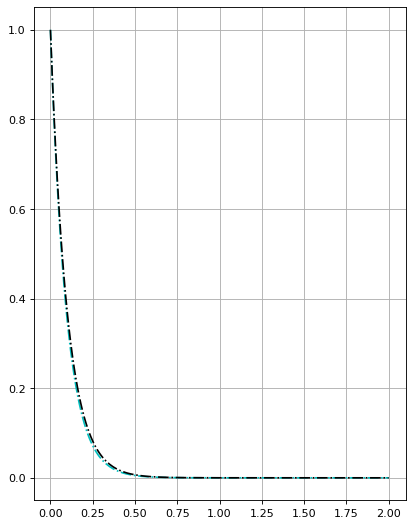

In [61]:
# Problema 1: crear un vector de tiempo
t0 = 0.0; tf = 2.0; dt = 0.01
tiempo = np.arange(t0,tf+dt,dt)
#print(tiempo)

# Problema 2: crear un vector para almacenar los valores de Y
yNum = np.zeros(len(tiempo))
#print(len(tiempo) == len(yNum))
# Problema 3: asginar la condición inicial y(0)=1
yNum[0] = 1.0
# Problema 4: crear una función para evaluar la derivada
F = lambda t,y: -10*y  #interpretelo como f(t,y), función lamba rapida y eficaz
Fan = np.zeros(len(tiempo))
Fan[0] = 1.0
Fan = lambda t: np.exp(-10*t)
ImFan = Fan(tiempo)
# Problema 5: método iterativo, ¿Qué ciclo usamos?
for i in range(1,len(tiempo)):
  yNum[i] = yNum[i-1] + F(tiempo[i-1], yNum[i-1])*dt
#print(yNum)
# Problema 6: el profe quiere ver una gráfica
y_axis = yNum
x_axis = tiempo
fig, ax = plt.subplots(1,1,figsize=(6,8),dpi=80)
#print(ImFan)
ax.plot(x_axis,y_axis,'c-.',x_axis,ImFan,'k-.')
ax.grid()

# Probando distintos dt

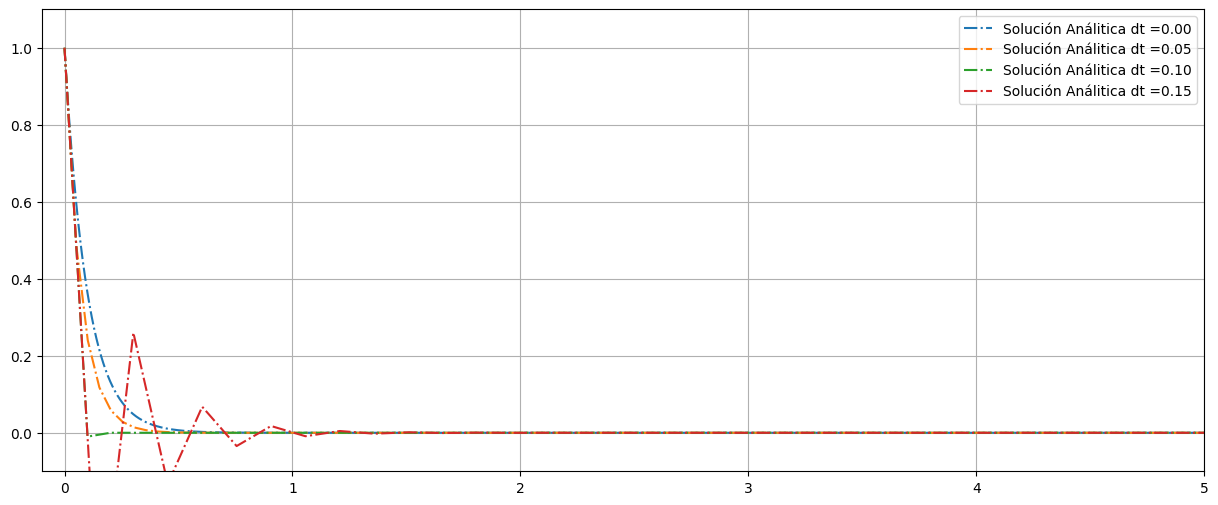

In [120]:
t_0 = 0; t_f = 5
delta = [dt for dt in np.arange(0.001, 0.2, 0.05)]
fig, ax = plt.subplots(1, 1, figsize = (15,6), dpi = 100)
for dt in delta:
    vect_t = np.arange(t_0, t_f + dt, dt)
    sol_num = np.zeros(len(vect_t))
    sol_num[0] = 1
    derivative = lambda y: -10*y 
    
    for num in range(0, len(vect_t)-1):
        sol_num[num+1] = sol_num[num] + derivative(sol_num[num])*dt
        
        
    ax.plot(vect_t, sol_num, '-.', label = f"Solución Análitica dt ={dt:.2f}")
ax.set_xlabel("")
ax.set_xlim([-0.1,t_f])
ax.set_ylim([-0.1,1.1])
ax.legend()
ax.grid()



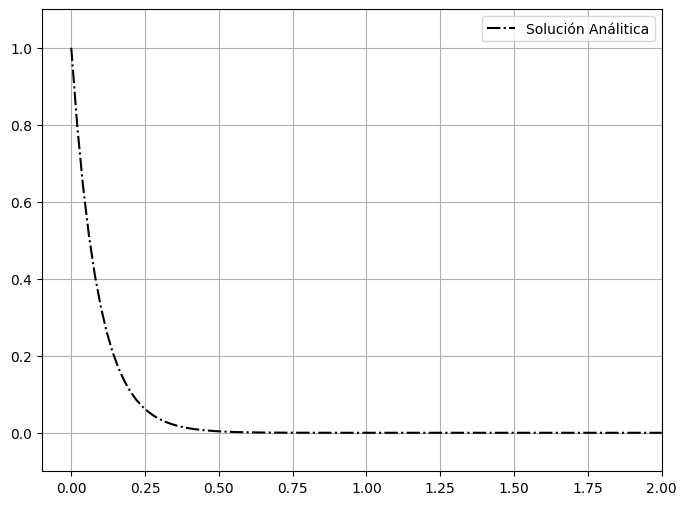

In [119]:
# Problema 1: crear un vector de tiempo
t_0 = 0; t_f = 2; dt = 0.02
vect_t = np.arange(t_0, t_f + dt, dt)
# Problema 2: crear un vector para almacenar los valores de Y
sol_num = np.zeros(len(vect_t))

# Problema 3: asginar la condición inicial y(0)=1
sol_num[0] = 1
# Problema 4: crear una función para evaluar la derivada
derivative = lambda y: -10*y 
# Problema 5: método iterativo, ¿Qué ciclo usamos?
for num in range(0, len(vect_t)-1):
    sol_num[num+1] = sol_num[num] + derivative(sol_num[num])*dt
# Problema 6: el profe quiere ver una gráfica
fig, ax = plt.subplots(1, 1, figsize = (8,6), dpi = 100)
ax.plot(vect_t, sol_num, 'k-.', label = "Solución Análitica")
ax.set_xlabel("")
ax.set_xlim([-0.1,t_f])
ax.set_ylim([-0.1,1.1])
ax.legend()
ax.grid()



Saque la solución Analitica \
Qué pasa cuando hago que dt "tienda a 0"

Funcion donde vemos a la EDO como los parametros de OTRA funcion $f(t,y)=y'=-10y $
```python
# Tu código aquí
F = lambda y,t: -10*y  #interpretelo como f(t,y)


Señales con transformada z

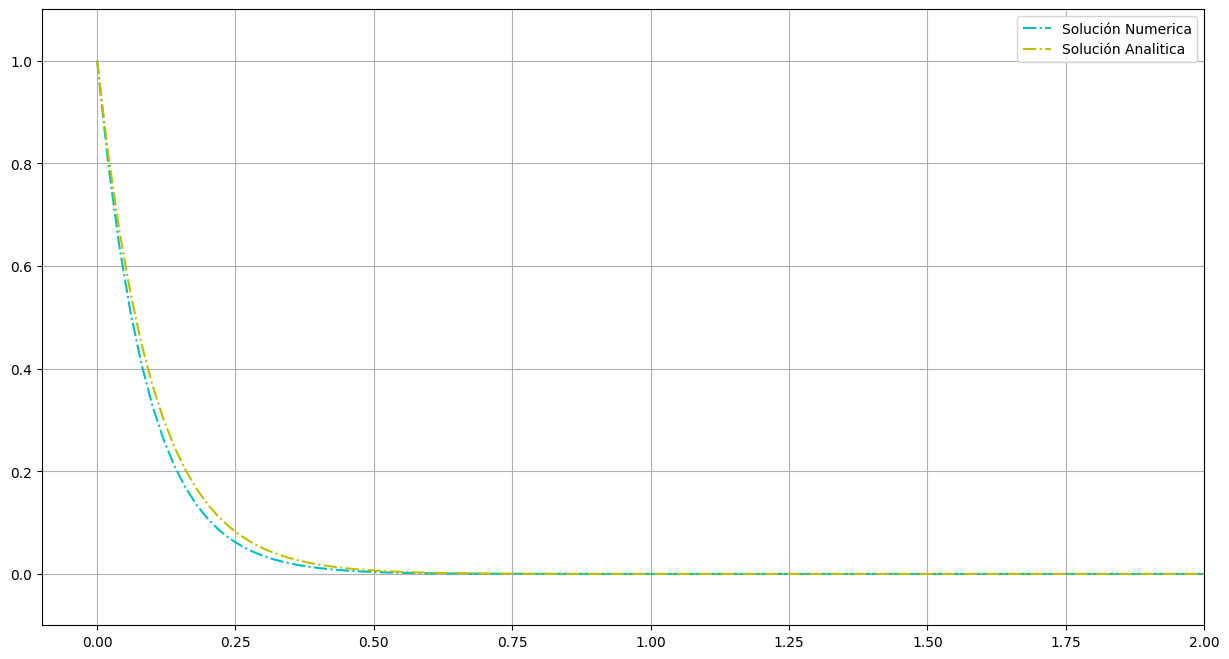

In [116]:
# Problema 7: crear una función que implemente la solución EF.
# Debe recibir como argumento t0, tf y deltaT

vect_t_an = np.arange(t0, t_f + dt,  dt)
# Debe retornar el vector tiempo y el vector Y para graficarlo afuera


# Problema 8: crear una función para la solución analítica

sol_an = lambda t: np.exp(-10*t)
sol_an = sol_an(vect_t_an)
#Problema 9: comparar la solución análitica y numérica
fig, ax = plt.subplots(1, 1, figsize = (15,8), dpi = 100)
ax.plot(vect_t, sol_num, 'c-.', label = "Solución Numerica")
ax.plot(vect_t_an, sol_an, 'y-.', label = "Solución Analitica")
ax.set_xlabel("")
ax.set_xlim([-0.1,t_f])
ax.set_ylim([-0.1,1.1])
ax.legend()
ax.grid()

<div align='justify'> Teniendo en cuenta que el error absoluto se define como: </div>

$$
    \text{Error Absoluto} = \left|\text{Valor real} - \text{Valor aproximado}\right|
$$

<br>
<div align='justify'> Y que el error relativo se define de la siguiente manera: </div> <br>

$$
    \text{Error relativo} = \frac{\text{Error Absoluto}}{ \left|\text{Valor real}\right|}
$$
<br>
<div align='justify'> Calcule el Error relativo de esta aproximación numérica, y produzca una gráfica de Error relativo vs tiempo. <b>¡Tenga cuidado con la división por cero!</b> </div> <br>


In [117]:
error_abs = np.zeros(len(sol_an))
error_rel = np.zeros(len(sol_an))
for elemento in range(len(sol_an)):
    error_abs[elemento] = np.abs(sol_an[elemento] - sol_num[elemento])
    error_rel[elemento] = error_abs[elemento] / sol_an[elemento]

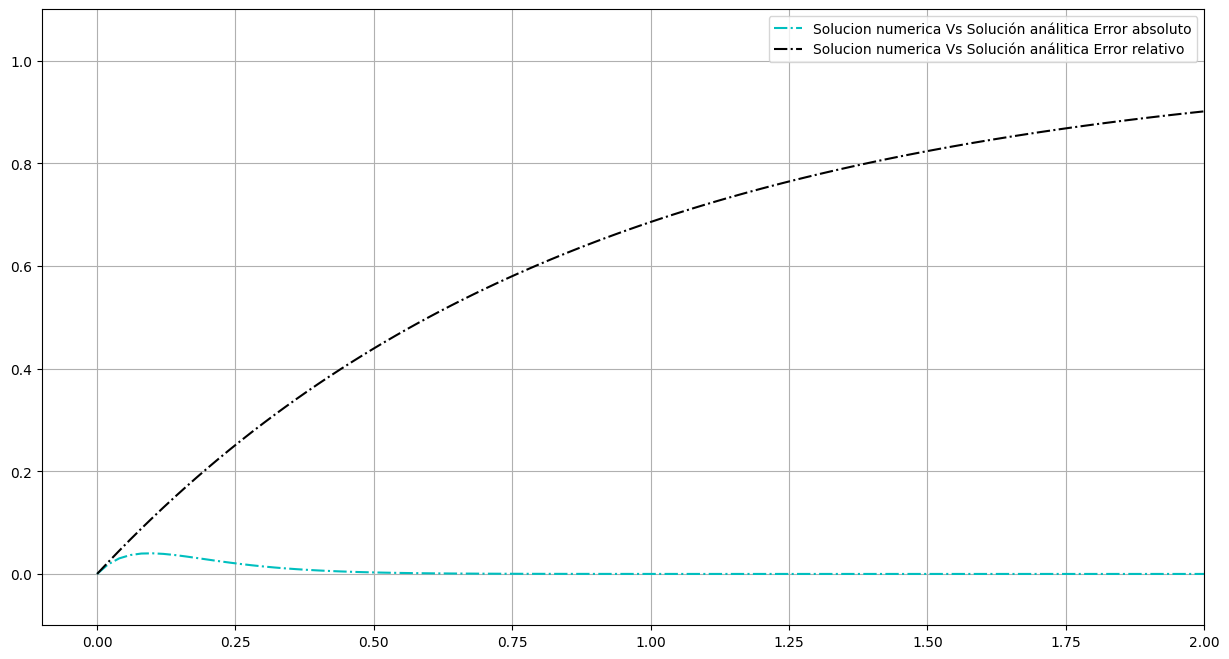

In [118]:
#Problema 9: comparar la solución análitica y numérica
fig, ax = plt.subplots(1, 1, figsize = (15,8), dpi = 100)
ax.plot(vect_t_an, error_abs, 'c-.', label = "Solucion numerica Vs Solución análitica Error absoluto")
ax.plot(vect_t_an, error_rel, 'k-.', label = "Solucion numerica Vs Solución análitica Error relativo")

ax.set_xlabel("")
ax.set_xlim([-0.1,t_f])
ax.set_ylim([-0.1,1.1])
ax.legend()
ax.grid()

### Experimentos computacionales

<div class="alert alert-block alert-info">
<b> ¿Qué ocurre si disminuimos el delta de tiempo? Recuerde que el error de este método es proporcional a $(\Delta t)^1$</b> </div>

<div class="alert alert-block alert-info">
<b> ¿Qué ocurre si el delta de tiempo es igual o mayor a 0.2? ¿Qué puede observar? ¿Tiene sentido físcio la solución? ¿Qué nombre le pondría a esta "solución"?</b> </div>

### Ejercicio 01:

Resuelva usando EF la siguiente ecuación diferencial ordinaria:

$$
    y^{\prime}(t)=-2t^{3}+12t^{2}-20t+8.5
$$

Con condición inicial $y(0) = 0$

Compare la solución numérica con la solución analítica. Simule hasta un tiempo de $3$ segundos.

In [136]:
t0 = 0; tf = 3; dt = 0.02
vect_t_num = np.arange(t0, tf + dt, dt)


sol_num = np.zeros(len(vect_t_num))
sol_num[0] = 0

derivative = lambda t: -2*t**3 + 12*t**2 - 20*t + 8.5

for i in range(len(vect_t_num)-1):
    sol_num[i+1] = sol_num[i] + derivative(vect_t_num[i])*dt
    

In [124]:
vect_t_an = np.arange(t0, tf + dt, dt)

sol_an = lambda t: -0.5*t**4 + 4*t**3 - 10*t**2 + 8.5*t

sol_an = sol_an(vect_t_an)

Text(0, 0.5, 'Y(t)')

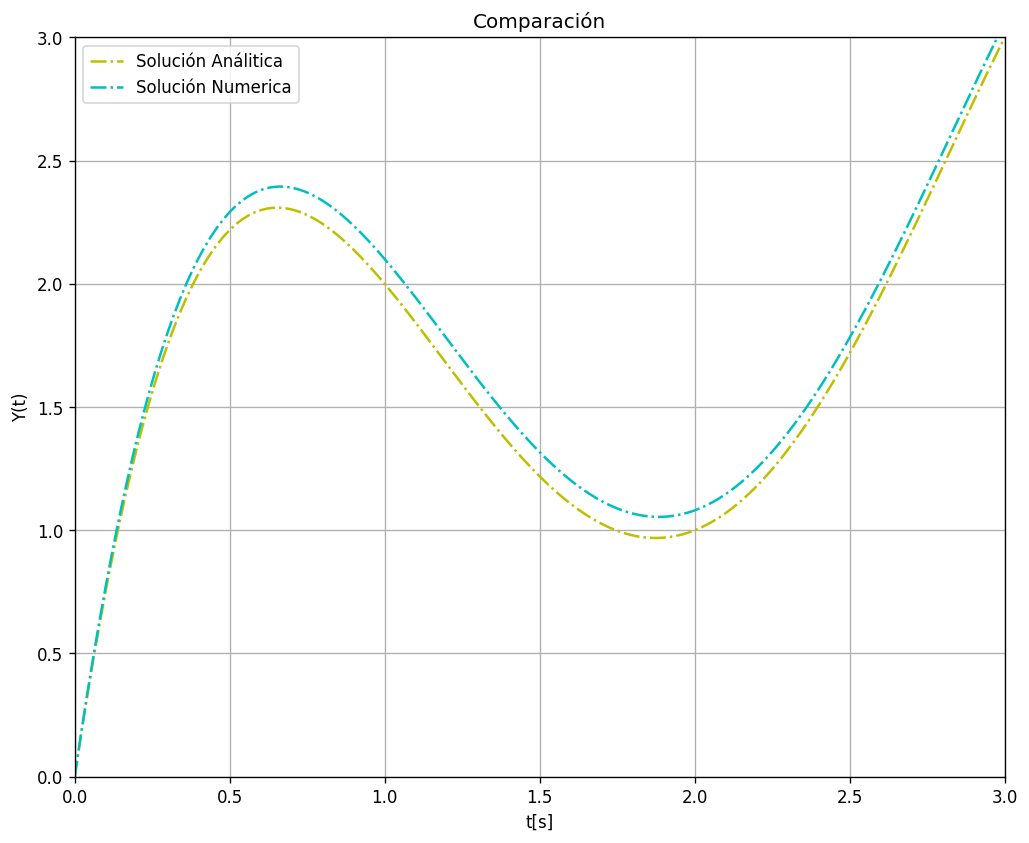

In [137]:
fig, ax = plt.subplots(1, 1, figsize = (10,8), dpi = 120)
ax.plot(vect_t_an, sol_an , 'y-.', label = "Solución Análitica")
ax.plot(vect_t_num, sol_num , 'c-.' , label = "Solución Numerica")
ax.grid()
ax.legend
ax.set_xlim([0,3])
ax.set_ylim([0,3])
ax.legend()
ax.set_title("Comparación")
ax.set_xlabel("t[s]")
ax.set_ylabel("Y(t)")

In [139]:
error_abs = np.abs(sol_an - sol_num)
error_rel = error_abs/np.abs(sol_an)

/tmp/ipykernel_320572/997898627.py:2: RuntimeWarning: invalid value encountered in divide
  error_rel = error_abs/np.abs(sol_an)


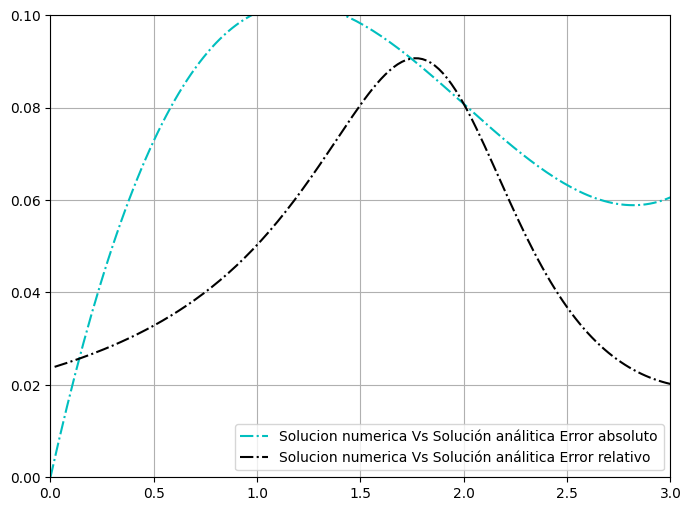

In [144]:
#Problema 9: comparar la solución análitica y numérica
fig, ax = plt.subplots(1, 1, figsize = (8,6), dpi = 100)
ax.plot(vect_t_an, error_abs, 'c-.', label = "Solucion numerica Vs Solución análitica Error absoluto")
ax.plot(vect_t_an, error_rel, 'k-.', label = "Solucion numerica Vs Solución análitica Error relativo")

ax.set_xlabel("")
ax.set_xlim([0,tf])
ax.set_ylim([0,0.1])
ax.legend()
ax.grid()

### Ejercicio 02:

¿Recuerda el ejercicio de la clase anterior? ¡El de la bola en caída libre! La EDO adimensional es:

$$
\frac{d^2z^*}{dt^{*2}} = -\frac{1}{{Fr}^2}
$$

Donde

$$
    Fr = \frac{w_0}{\sqrt{z_0g}}
$$

¿Qué haría para encontrar la solución numérica a esta EDO? Emplee $Fr = 1.0$, $w_0 = 2.0~m/s$, $g = -9.81~m/s^2$



# Planteamos lo Principal
$$
z^*(t^*) = \dfrac{z_0}{\left| z_0 \right|} + \dfrac{w_0}{\left| w_0 \right|}-\dfrac{1}{2\cdot {Fr}^2}t^{*2}
$$
$$
t^* = \dfrac{t}{t_c} 
$$

In [45]:
def sol_num(Fr, w0, g, dt=0.02):
    z0 = w0**2 / (Fr**2 * g)
    # Encontrar tf
    Coef = [-1 / (2*Fr**2), w0 / np.abs(w0), z0 / np.abs(z0)]
    poli = np.poly1d(Coef) 
    for i in np.roots(poli):
        if i > 0:
            tf = i
    # Parametros y Vector de Tiempo
    t0 = 0
    vect_t_num = np.arange(t0, tf + dt, dt)
    # Vector de la segunda derivada y primera
    vel = np.zeros(len(vect_t_num))
    z_num = np.zeros(len(vect_t_num))
    # Solucion del runge kutta
    f_sol_first = lambda z: -1 / Fr**2
    # Condicion inicial !!SEGUNDA DERIVADA y Primera
    vel[0] = w0 / np.abs(w0)
    z_num[0] = z0 / np.abs(z0) 
    # Solucion primer orden
    for i in np.arange(len(vect_t_num)-1):
        vel[i+1] = vel[i] + f_sol_first(vel[i])*dt
        z_num[i+1] = z_num[i] + vel[i]*dt
    # Retornar lo necesario
    return z_num, vect_t_num

In [46]:
def sol_an(Fr, w0, g, dt=0.02):
    z0 = w0**2 / (Fr**2 * g)
    # Encontrar tf
    Coef = [-1 / (2*Fr**2), w0 / np.abs(w0), z0 / np.abs(z0)]
    poli = np.poly1d(Coef) 
    for i in np.roots(poli):
        if i > 0:
            tf = i
    # Parametros y Vector de Tiempo
    t0 = 0
    vect_t_an = np.arange(t0, tf + dt, dt)
    # Fincion Solucion
    z_an = np.zeros(len(vect_t_an))
    
    # Condicion inicial !!SEGUNDA DERIVADA y Primera
    z_an[0] = z0 / np.abs(z0) 
    # Solucion primer orden
    for i in np.arange(len(vect_t_an)):
        z_an[i] = z0 / np.abs(z0) + (w0 * vect_t_an[i]) / np.abs(w0) -  vect_t_an[i]**2 / (2 * Fr**2)
        
    # Retornar lo necesario
    return z_an, vect_t_an, tf

In [63]:
Fr = 1.0; w0 = 2.0; g = 9.81; dt = 0.06
z_num, t_adim = sol_num(Fr, w0, g, dt)
z_an, t_adim_an, tf = sol_an(Fr, w0, g, dt)

Text(0, 0.5, 'z* []')

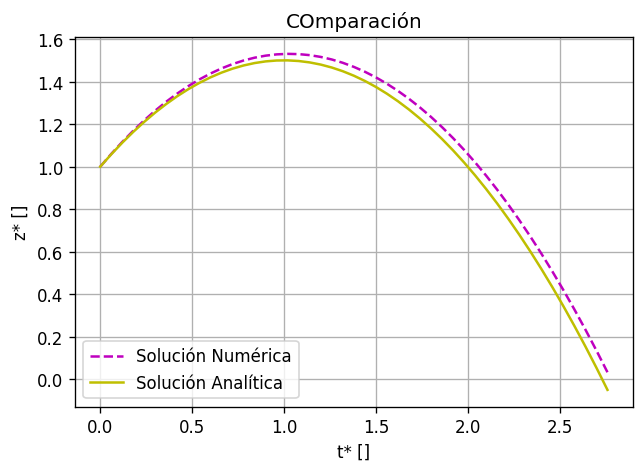

In [64]:
fig, ax = plt.subplots(1, 1, figsize = (6,4), dpi = 120)
ax.plot(t_adim, z_num, "m--", label = "Solución Numérica")
ax.plot(t_adim_an, z_an, "y-", label = "Solución Analítica")
ax.grid()
ax.legend()
ax.set_title("COmparación")
ax.set_xlabel("t* []")
ax.set_ylabel("z* []")


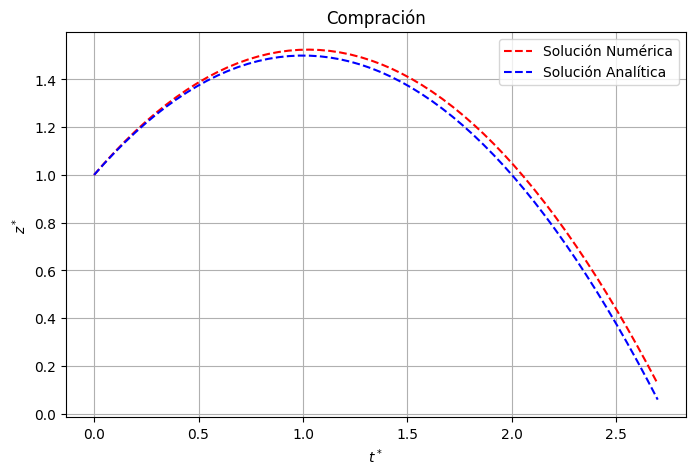

<div align='justify'> Del mismo modo que se hizo para el ejercicio anterior, calcule el error relativo de esta aproximación numérica y grafique este error vs el tiempo. </div>



Text(0, 0.5, 'z* []')

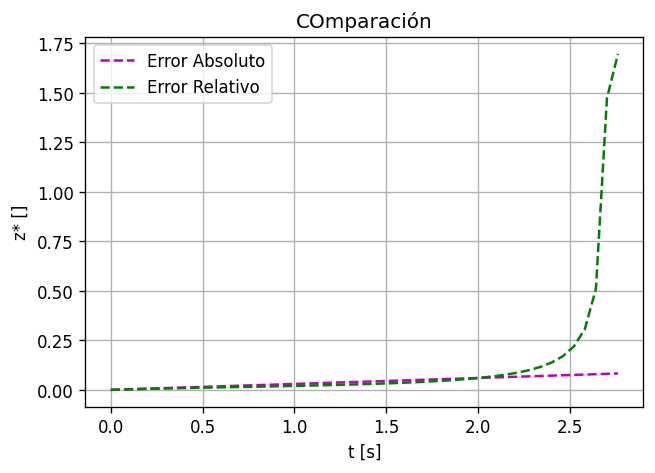

In [67]:
error_abs = np.abs(z_an - z_num)
error_rel = error_abs / np.abs(z_an)
fig, ax = plt.subplots(1, 1, figsize = (6,4), dpi = 120)
ax.plot(t_adim, error_abs, "m--", label = "Error Absoluto")
ax.plot(t_adim_an,error_rel, "g--", label = "Error Relativo")
ax.grid()
ax.legend()
ax.set_title("COmparación")
ax.set_xlabel("t [s]")
ax.set_ylabel("z* []")


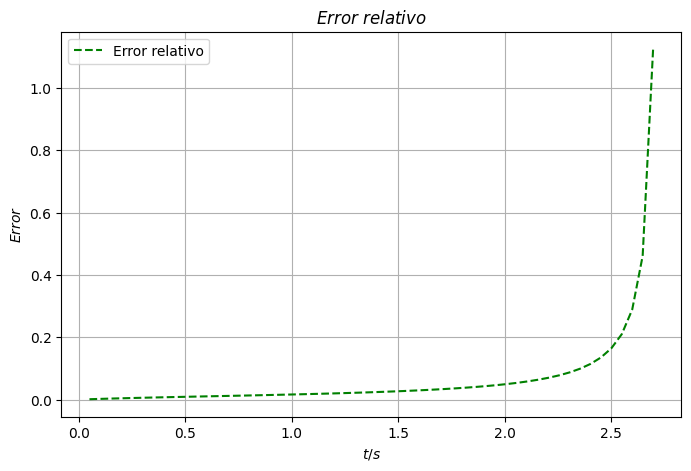

### Ejercicio 03:

<div align='justify'> Hasta este momento hemos resuelto Ecuaciones Diferenciales Ordinarias de primer orden !Fácil¡ ¿Verdad? ¿Qué tal un pequeño reto? ¿Qué tal si intentamos resolver un Sistema de Ecuaciones Diferenciales de primer orden? La idea sería resolverlo con Euler Hacia Adelante (Euler Forward). Aquí va: </div>

\begin{align}
    & \frac{dx(t)}{dt}=  \frac{1}{10}y(t) -\frac{1}{5}x(t)=f(x,y) \\
    & \frac{dy(t)}{dt}= \frac{1}{4}x(t) -\frac{1}{5}y(t)=g(x,y)
\end{align}

Con condiciones iniciales $x(0) = 18$ y $y(0)=40$

In [69]:
# Definicion Vector TIempo
t0 = 0;tf = 15; dt = 0.02
vect_t = np.arange(t0, tf + dt, dt)
# funciones rk
f = lambda x, y: y / 10 - x / 5
g = lambda x, y: x / 4 - y / 5 
# Funciones SOlución
x = np.zeros(len(vect_t))
y = np.zeros(len(vect_t))
# Valor Inicial en cada una
x[0] = 18
y[0] = 40

# General Solucion
for i in np.arange(len(vect_t)-1):
    x[i+1] = x[i] + f(x[i], y[i]) * dt
    y[i+1] = y[i] + g(x[i], y[i]) * dt

(0.0, 41.42349093800641)

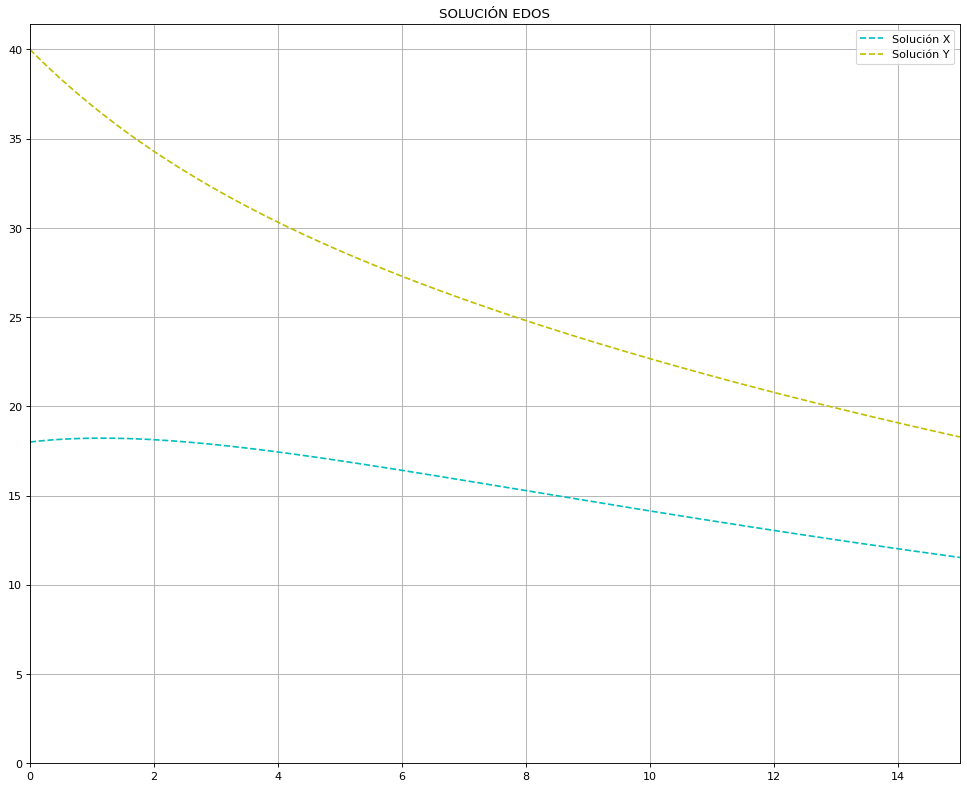

In [77]:
fig, ax = plt.subplots(1, 1, figsize = (15,12), dpi = 80)
ax.plot(vect_t, x, 'c--', label = "Solución X")
ax.plot(vect_t, y, 'y--', label = "Solución Y")
ax.grid()
ax.legend()
ax.set_title("SOLUCIÓN EDOS")
ax.set_xlim([0,tf])
ax.set_ylim(0,None)

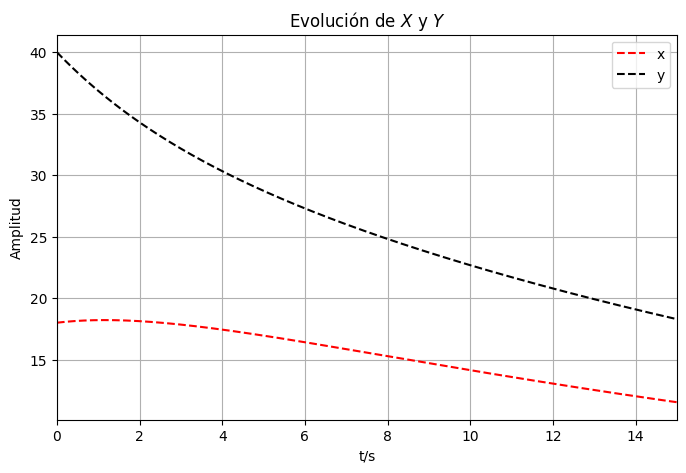